# Data Analysis

In [1]:
# libraries
import pandas as pd
import numpy as np
import functools as ft
import seaborn as sns
import matplotlib.pyplot as plt

#otros
import time
import warnings
warnings.filterwarnings('ignore')

# Carga de datos    

In [2]:
dt = pd.read_csv("/home/estebanm/Escritorio/docs_tfm/proyecto_tfm/data/bronze/audio_features_ivanova_dataset.csv")
dt.head()

,sujeto,audio_file,dementia,label,gender,age,total_words,total_sentences,sentence_length_mean,sentence_length_std,...,pause_duration_mean,pause_time_ratio,speech_segment_duration_mean,speech_segment_duration_cv,pause_duration_skewness,pause_duration_kurtosis,voiced_ratio,mmse_df_info,schooling_years,articulation_rate_wpm
0,163,AD-M-57-163.wav,2,ad,M,57,71,4,17.750000,14.872374,...,0.329075,0.250182,0.867556,0.703391,2.069982,4.332522,0.708787,13.0,17.0,64.482952
1,40,AD-M-65-40.wav,2,ad,M,65,70,3,23.333333,3.399346,...,0.344533,0.250000,0.612211,0.645111,1.558600,1.956037,0.562693,28.0,NaN,135.489676
2,285,AD-M-67-285.wav,2,ad,M,67,77,4,19.250000,8.842370,...,0.384000,0.250217,0.892690,0.718931,3.689300,15.348264,0.702867,23.0,17.0,167.357083
3,272,AD-M-69-272.wav,2,ad,M,69,68,1,68.000000,0.000000,...,0.337778,0.250219,2.122000,1.420813,0.457952,-0.760515,0.931519,28.0,12.0,149.300752
4,314,AD-M-72-314.wav,2,ad,M,72,66,3,22.000000,13.140269,...,0.468571,0.250203,0.578000,0.515021,1.403975,1.385860,0.705452,19.0,8.0,67.159085


###  Revisiones Generales

In [3]:
# Revisando el esquema de las variables
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 52 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   sujeto                        357 non-null    int64  
 1   audio_file                    357 non-null    object 
 2   dementia                      357 non-null    int64  
 3   label                         357 non-null    object 
 4   gender                        357 non-null    object 
 5   age                           357 non-null    int64  
 6   total_words                   357 non-null    int64  
 7   total_sentences               357 non-null    int64  
 8   sentence_length_mean          357 non-null    float64
 9   sentence_length_std           357 non-null    float64
 10  type_token_ratio              357 non-null    float64
 11  mattr_50                      357 non-null    float64
 12  noun_ratio                    357 non-null    float64
 13  conte

In [4]:
# Revisiones estadisticas de las variables

dt.describe().T

,count,mean,std,min,25%,50%,75%,max
sujeto,357.0,1.807899e+02,1.046157e+02,1.000000,91.000000,180.000000,271.000000,3.620000e+02
dementia,357.0,6.610644e-01,8.002612e-01,0.000000,0.000000,0.000000,1.000000,2.000000e+00
age,357.0,7.725490e+01,8.630981e+00,50.000000,70.000000,79.000000,84.000000,9.600000e+01
total_words,357.0,6.968347e+01,8.523799e+00,43.000000,66.000000,67.000000,71.000000,1.440000e+02
total_sentences,357.0,3.478992e+00,2.870370e+00,1.000000,1.000000,3.000000,5.000000,3.000000e+01
sentence_length_mean,357.0,3.319982e+01,2.281132e+01,3.266667,14.200000,24.333333,50.000000,9.500000e+01
sentence_length_std,357.0,5.416333e+00,5.518823e+00,0.000000,0.000000,5.408327,7.542472,2.750000e+01
type_token_ratio,357.0,7.023107e-01,3.968402e-02,0.450000,0.691176,0.712121,0.723077,7.761194e-01
mattr_50,357.0,7.435705e-01,3.716038e-02,0.560000,0.731000,0.751765,0.761538,8.190909e-01
noun_ratio,357.0,2.980284e-01,4.421717e-02,0.137255,0.264706,0.301887,0.333333,3.857143e-01


<Axes: ylabel='proportion'>

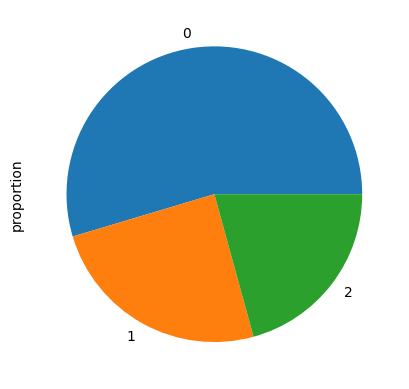

In [5]:
# Revisando la variable dependiente. Los valores 1, 2 son asociados con dementia, y el valor 0 con la no presencia de sintomas

dt.dementia.value_counts(normalize=True).plot(kind='pie')

**Observaciones**:
* El dataset muestra un balanceo natural de los datos, es decir, los porcetajes de los grupos (0, 1, 2) son considerablemente bien repartidos (no hay un grupo que aglutine la mayor parte de los datos), lo ayuda a que un modelo de machine learning sea capaz de aprender de los patrones implicitos en los datos y pueda realizar una buena predicción.
* Se podría suponer que no es necesario balancear los datos para realizar los modelos. Se harán las respectivas pruebas en su momento.

<Axes: ylabel='age'>

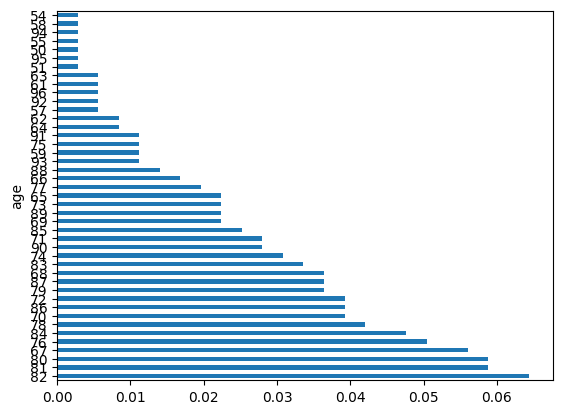

In [6]:
# Revisando la variable edad --> probable que requiera transformarla en variable con rangos de categorias

dt.age.value_counts(normalize=True).plot(kind='barh')

**Observaciones:**

* Se observan una serie de grupos en las edades, es decir, concentraciones en algunos rangos de edades
* El valor en la problación es de 82 años y muestra una clara concentración de más del 6% de la población del dataset
* Los valores mínimos de edades están rondando los 54 años

<Axes: ylabel='schooling_years'>

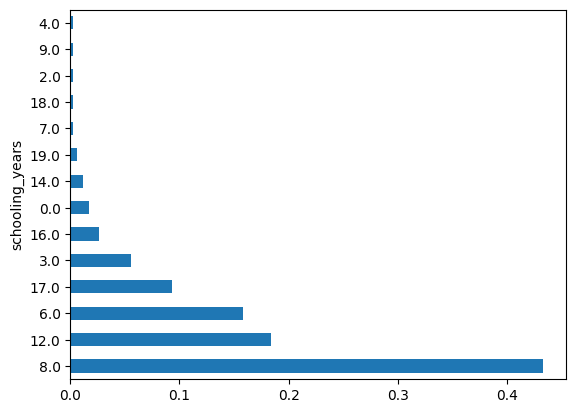

In [7]:
# Revisando la variable tiempo de escolaridad --> es necesario revisar la posibilidad de transformarla en variable con rangos de categorias
dt.schooling_years.value_counts(normalize=True).plot(kind='barh')

**Observaciones:**

* Se observa una clara preponderacia de 8 años de estudio con un poco más del 40% de la población del análisis.
* Los valores asociados a poblaciones con estudios superiores son bajos, lo que refleja un comportamiento bastante normal en la población, es decir, sólo unos cuantos individuos realizan estudios más allá del pregrado.

### Valores perdidos

In [8]:
def check_null_values(df):
    """ Revisiones de valores perdidos en el dataset"""
    missing_values = pd.DataFrame({
        'Variable': df.columns,
        'Faltantes':df.isnull().sum(),
        'Porcentaje': (df.isnull().sum()/len(df)*100).round(2),
        'Tipo': df.dtypes
    })
    

    return missing_values

In [9]:
# Revisiones de los valores perdidos en la variables de analisis
check_null_values(dt)

,Variable,Faltantes,Porcentaje,Tipo
sujeto,sujeto,0,0.00,int64
audio_file,audio_file,0,0.00,object
dementia,dementia,0,0.00,int64
label,label,0,0.00,object
gender,gender,0,0.00,object
age,age,0,0.00,int64
total_words,total_words,0,0.00,int64
total_sentences,total_sentences,0,0.00,int64
sentence_length_mean,sentence_length_mean,0,0.00,float64
sentence_length_std,sentence_length_std,0,0.00,float64


**Observaciones:**

* Se detecta la presencia de valores perdidos en las variable mmse_df_info, schooling_years, local_coherence_bigram.
* Considerando la proporciones de valores perdidos, no son porcentajes que afecte las variables de forma considerable, por lo que buscaran métodos de imputación para estos valores.
  

## Detecciones de outliers

In [10]:
def detect_outliers_iqr(df, multiplier=1.5):
    df = df.select_dtypes(include=['int64', 'float64'])
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - (multiplier * IQR)
    upper_bound = Q3 + (multiplier * IQR)
    return (df < lower_bound) | (df> upper_bound)

In [11]:
# Revisiones de valores atipicos: se sumariza las variables que tienen almenos un valor atipico

outliers = detect_outliers_iqr(dt)
pos_outliers = outliers.loc[outliers.any(axis=1), outliers.any(axis=0)].sum()
pos_outliers

total_words                     47
total_sentences                  4
sentence_length_std             13
type_token_ratio                26
mattr_50                        28
noun_ratio                       1
content_verb_ratio               7
adj_adv_ratio                   28
function_word_ratio             22
lexical_repetitions             39
reformulations                  61
fillers                         63
local_coherence_bigram          65
lexical_error_rate               5
pronoun_to_propn_ratio          36
mean_word_length                16
readability                     10
speech_rate_wpm                  2
f0_mean                          8
f0_std                          20
f0_range                        16
loudness_mean                   11
loudness_std                     4
jitter_local                    22
shimmer_local                   10
hnr                              4
alpha_ratio                     15
hammarberg_index                 3
spectral_slope_mean 

**Observaciones:**
* Se observa la presencia de valores outliers en muchas de las variables del dataset.
* Se debe considerar la posibilidad de buscar modelos robustos a la presencia de valores outliers.
* Se va a verificar si la presencia de outliers obedece a la presencia de la enfermedad

## Revisiones Gráficas

In [12]:
def histogram(df):
    var_num = df.select_dtypes(include=['int64', 'float64'])
    num_cols = len(var_num.columns)

    fig = plt.figure(figsize=(15, 5 *((num_cols + 2)// 4)))

    for idx, col in enumerate(var_num.columns, 1):
        ax = fig.add_subplot((num_cols + 2) // 3, 4, idx)
        ax.hist(var_num[col], bins=30, edgecolor='black', alpha=0.7)
        ax.set_title(f"Histograma: {col}", fontweight='bold')
        ax.set_xlabel(col)
        ax.set_ylabel('Frecuencia')
        ax.grid(alpha=0.3)
    plt.tight_layout()



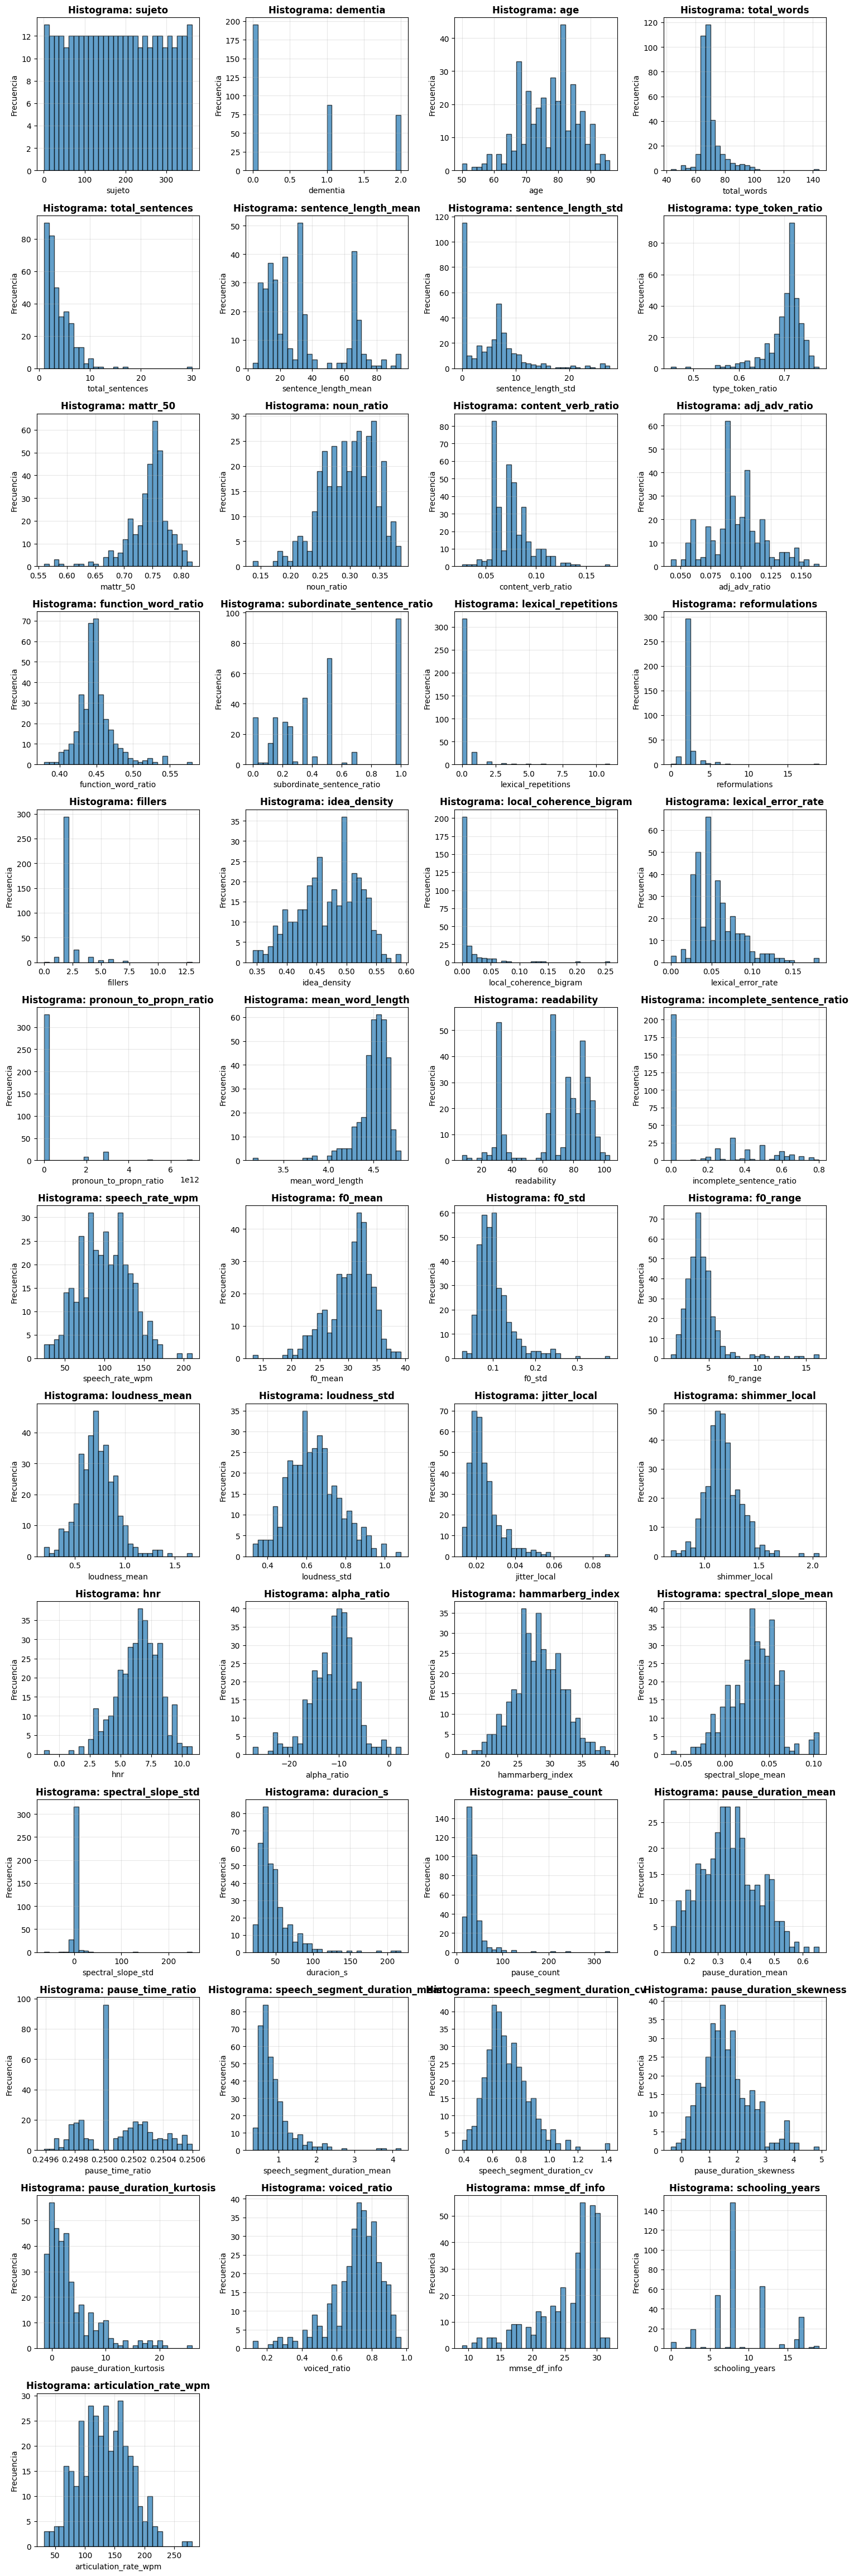

In [13]:
# generando los histogramas para las variables de trabajo
histogram(dt)

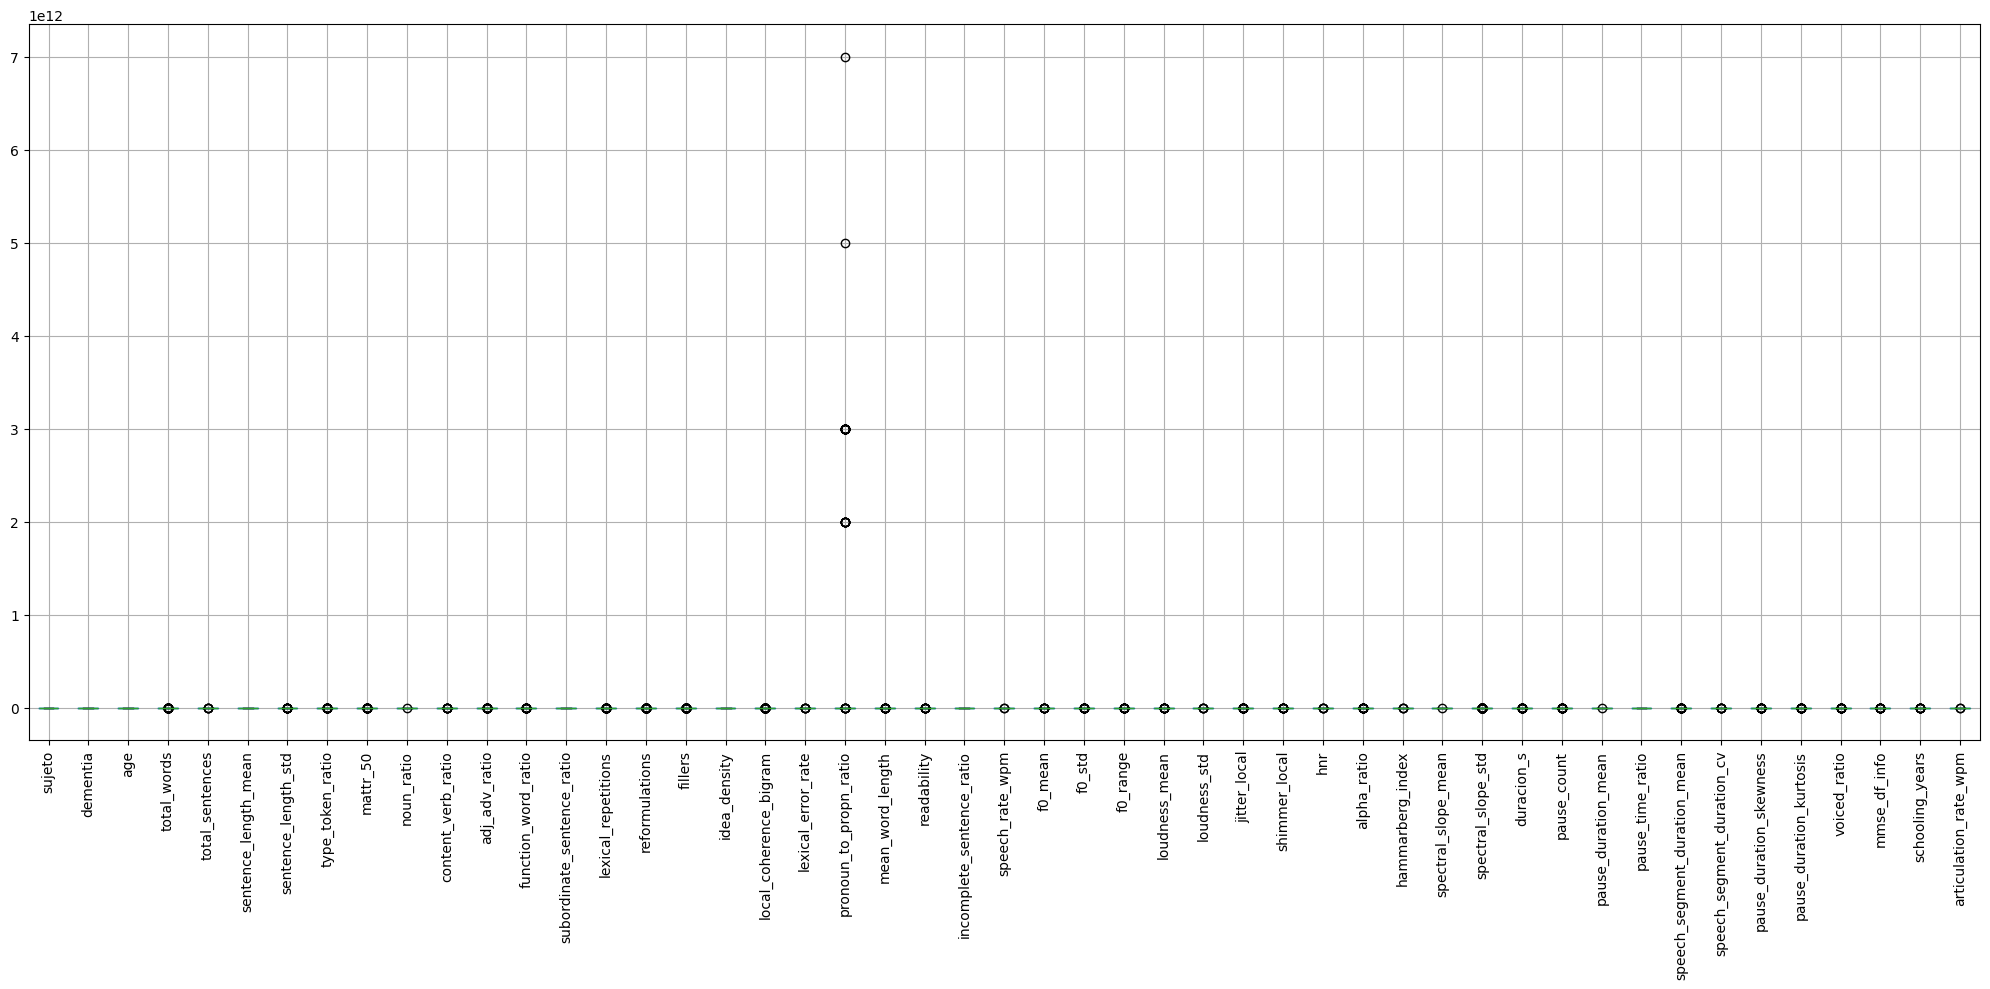

In [14]:
# Revisando los boxplot de las variables
def boxplots(df):
    var_num = df.select_dtypes(include=['int64', 'float64']).boxplot(figsize=(20,10))
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

boxplots(dt)

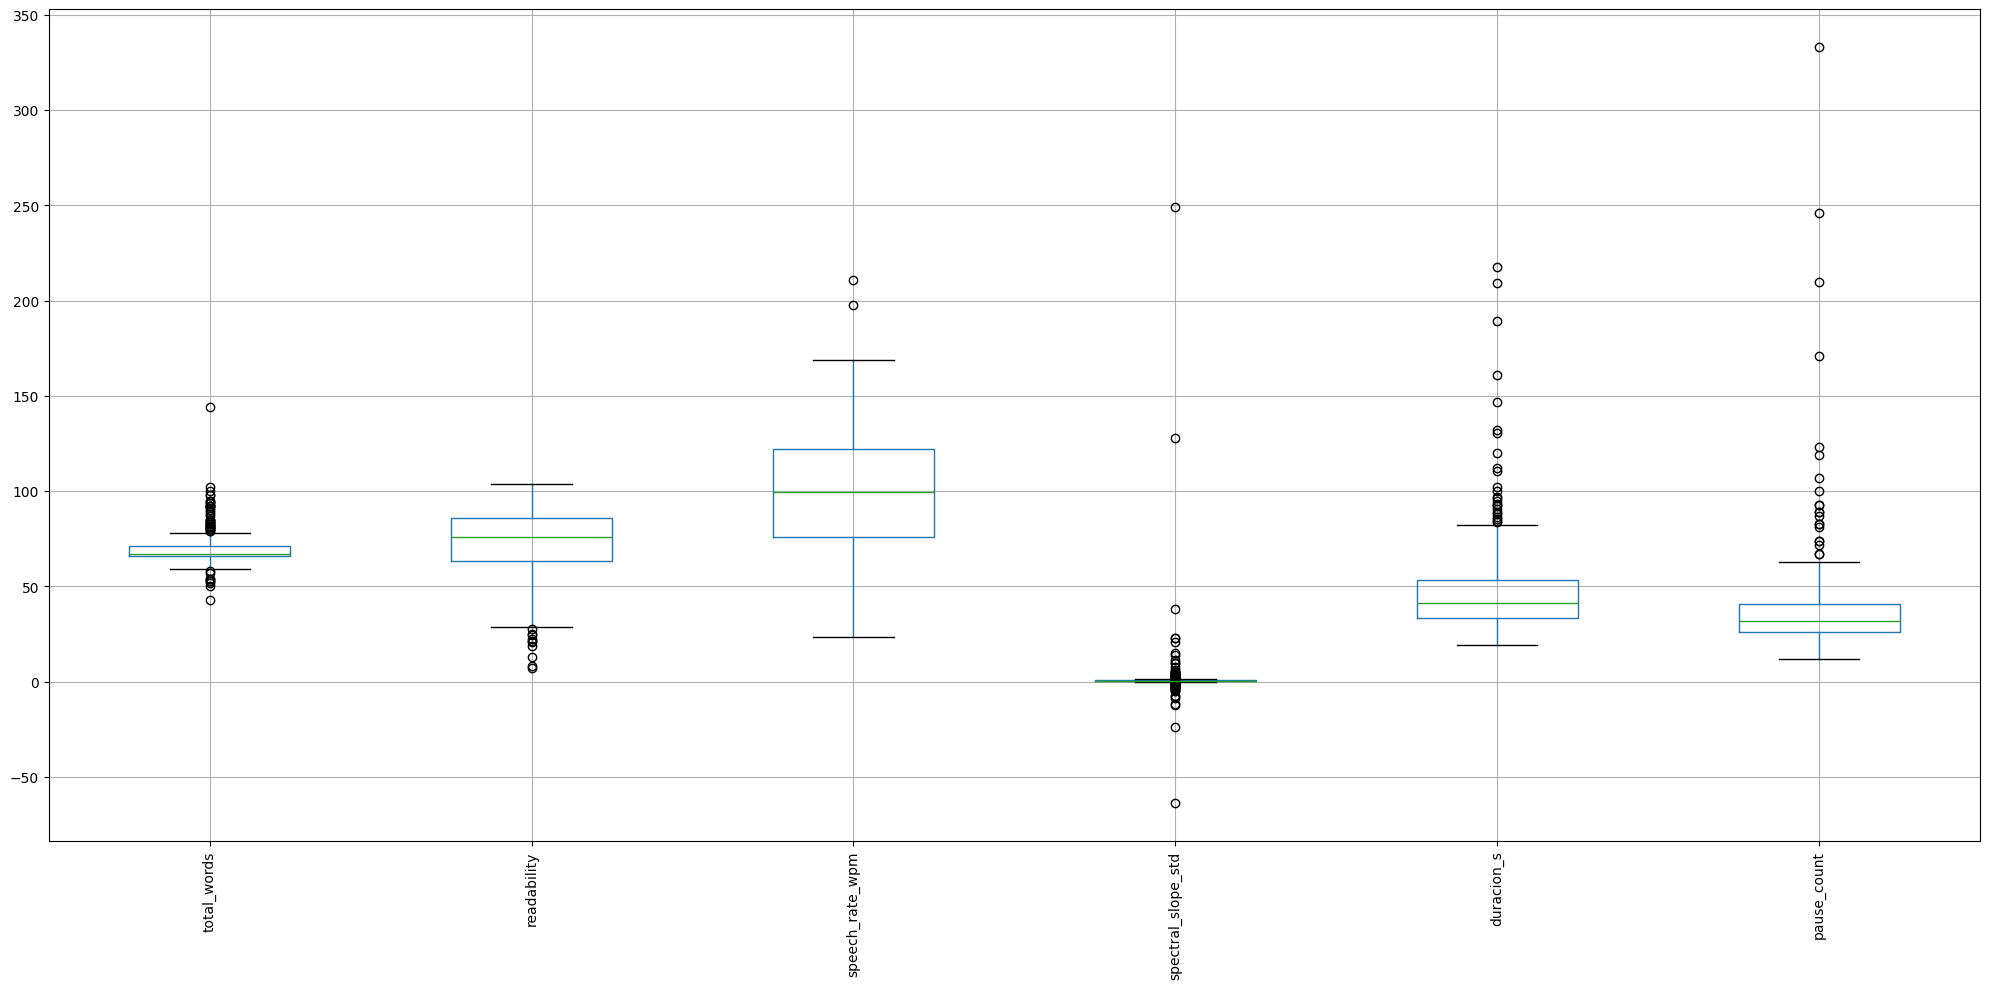

In [15]:
# Variables con mayores proporciones de valores outliets

dt_upper = dt[['total_words', 'readability', 'speech_rate_wpm', 'spectral_slope_std', 'duracion_s', 'pause_count']]

boxplots(dt_upper)

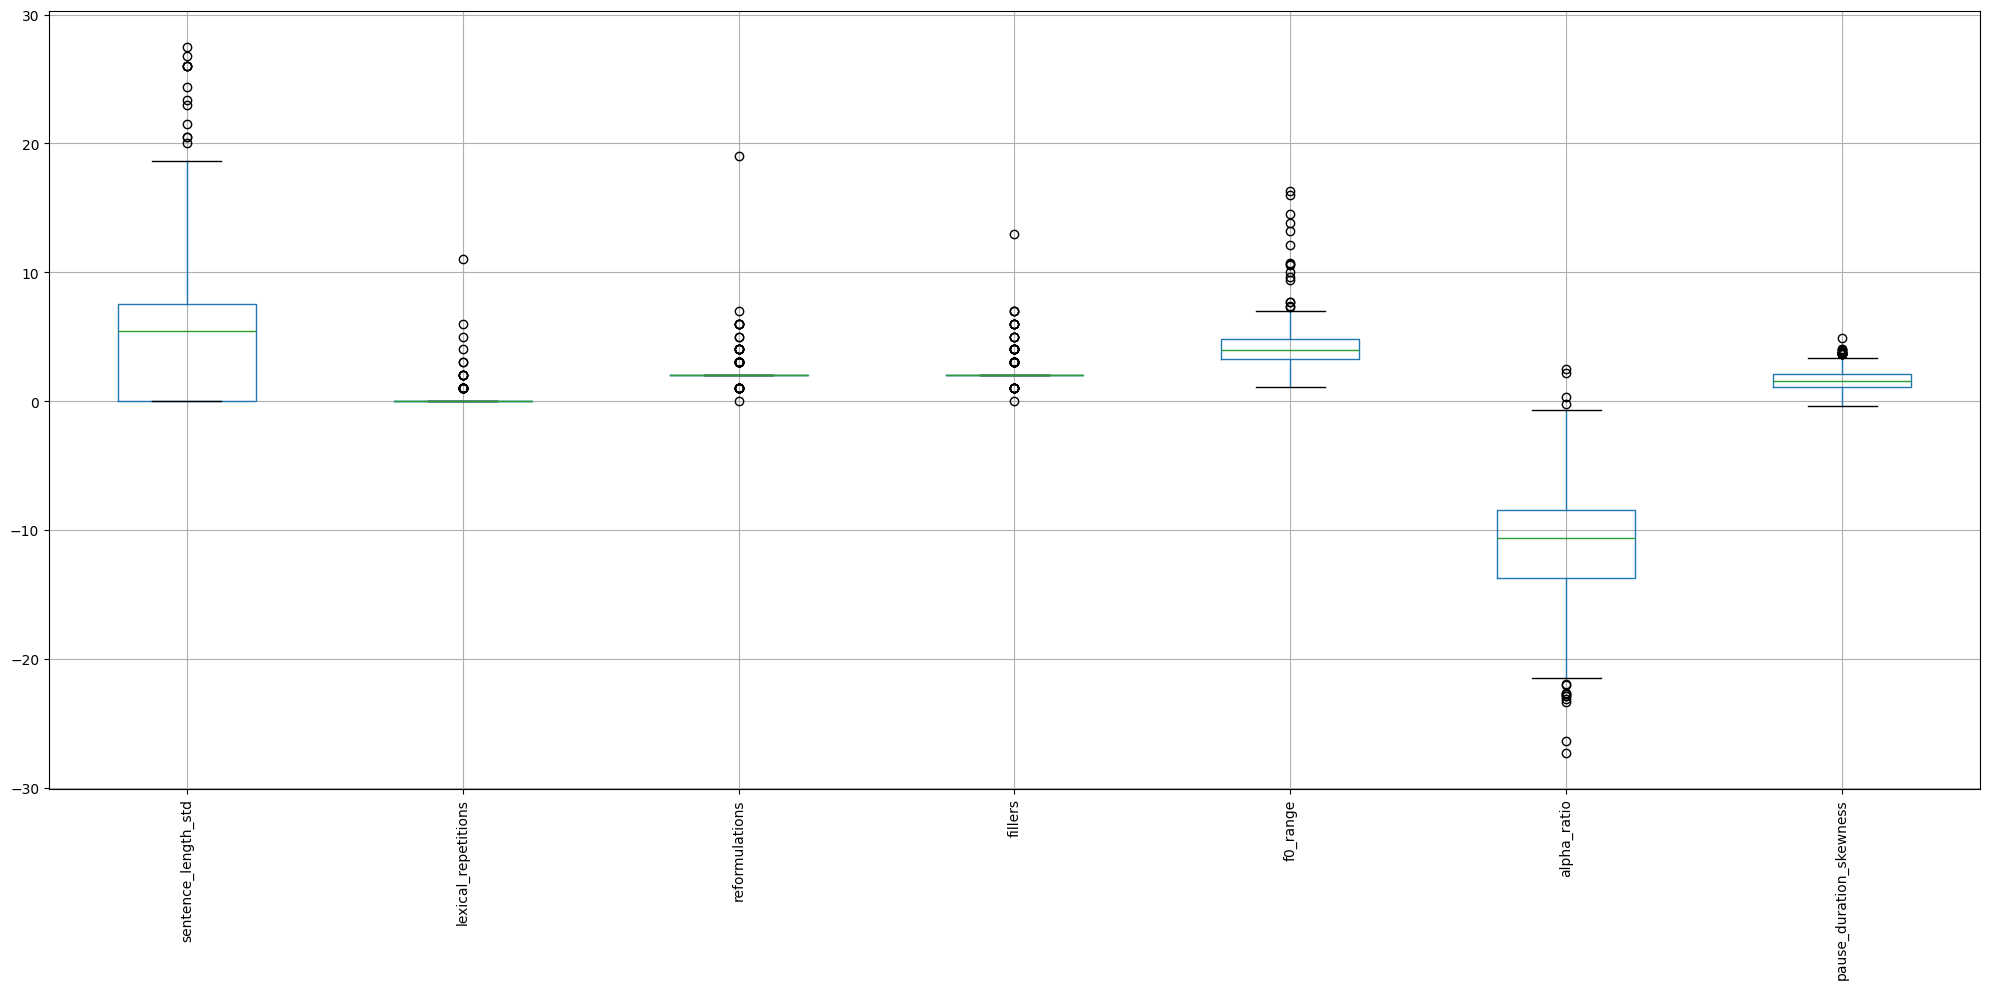

In [16]:
# variables intermedias en materia de cantidad de valores outliets
dt_intermediate = dt[['sentence_length_std', 'lexical_repetitions','reformulations',
       'fillers', 'f0_range','alpha_ratio', 'pause_duration_skewness']]
boxplots(dt_intermediate)

In [17]:
# En haras de simplificar el analisis en la variable dependiente, todos los casos que tiene factores asociados a AD, seran unidos bajo una sola variable, entonces
# dementia1=1, se consideran casos positivos y los casos negativos dementia1=0
dt_new = dt.copy()
dt_new['dementia1'] = dt_new['dementia'].replace(2, 1)

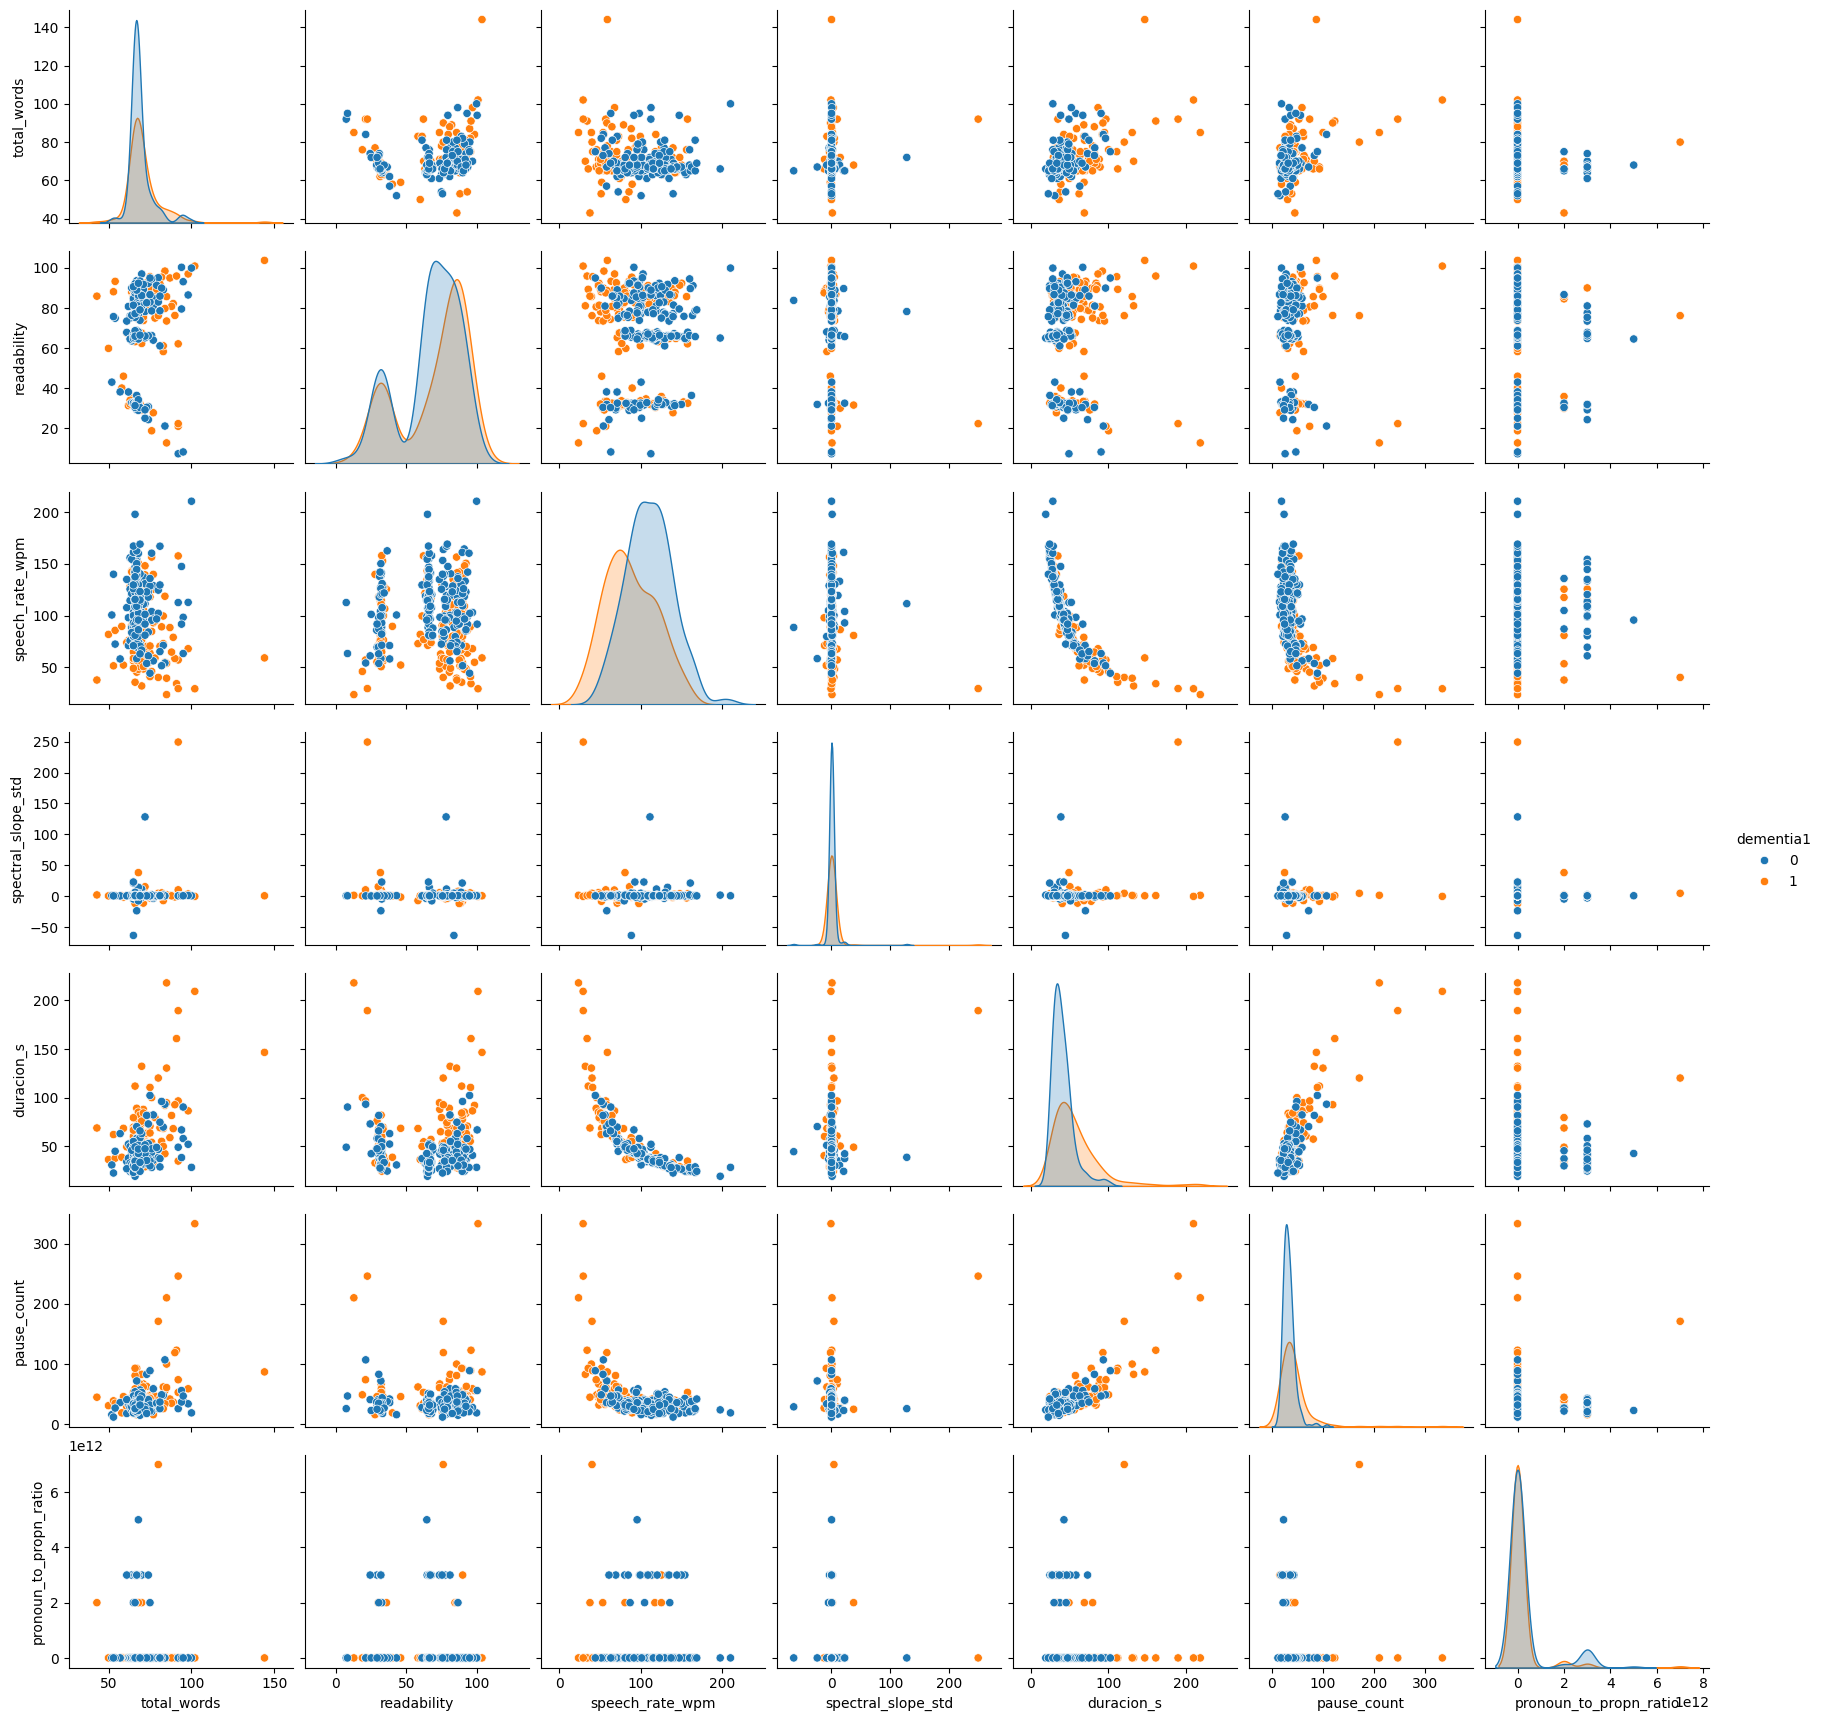

In [18]:
# Revisemos relaciones de las variables con valores extremos y la variable dependiente
dt_upper = dt_new[['total_words', 'readability', 'speech_rate_wpm', 'spectral_slope_std', 'duracion_s', 'pause_count',
                  'pronoun_to_propn_ratio', 'dementia1' ]]
pairplot_data = dt_upper
sns.pairplot(pairplot_data, hue='dementia1')

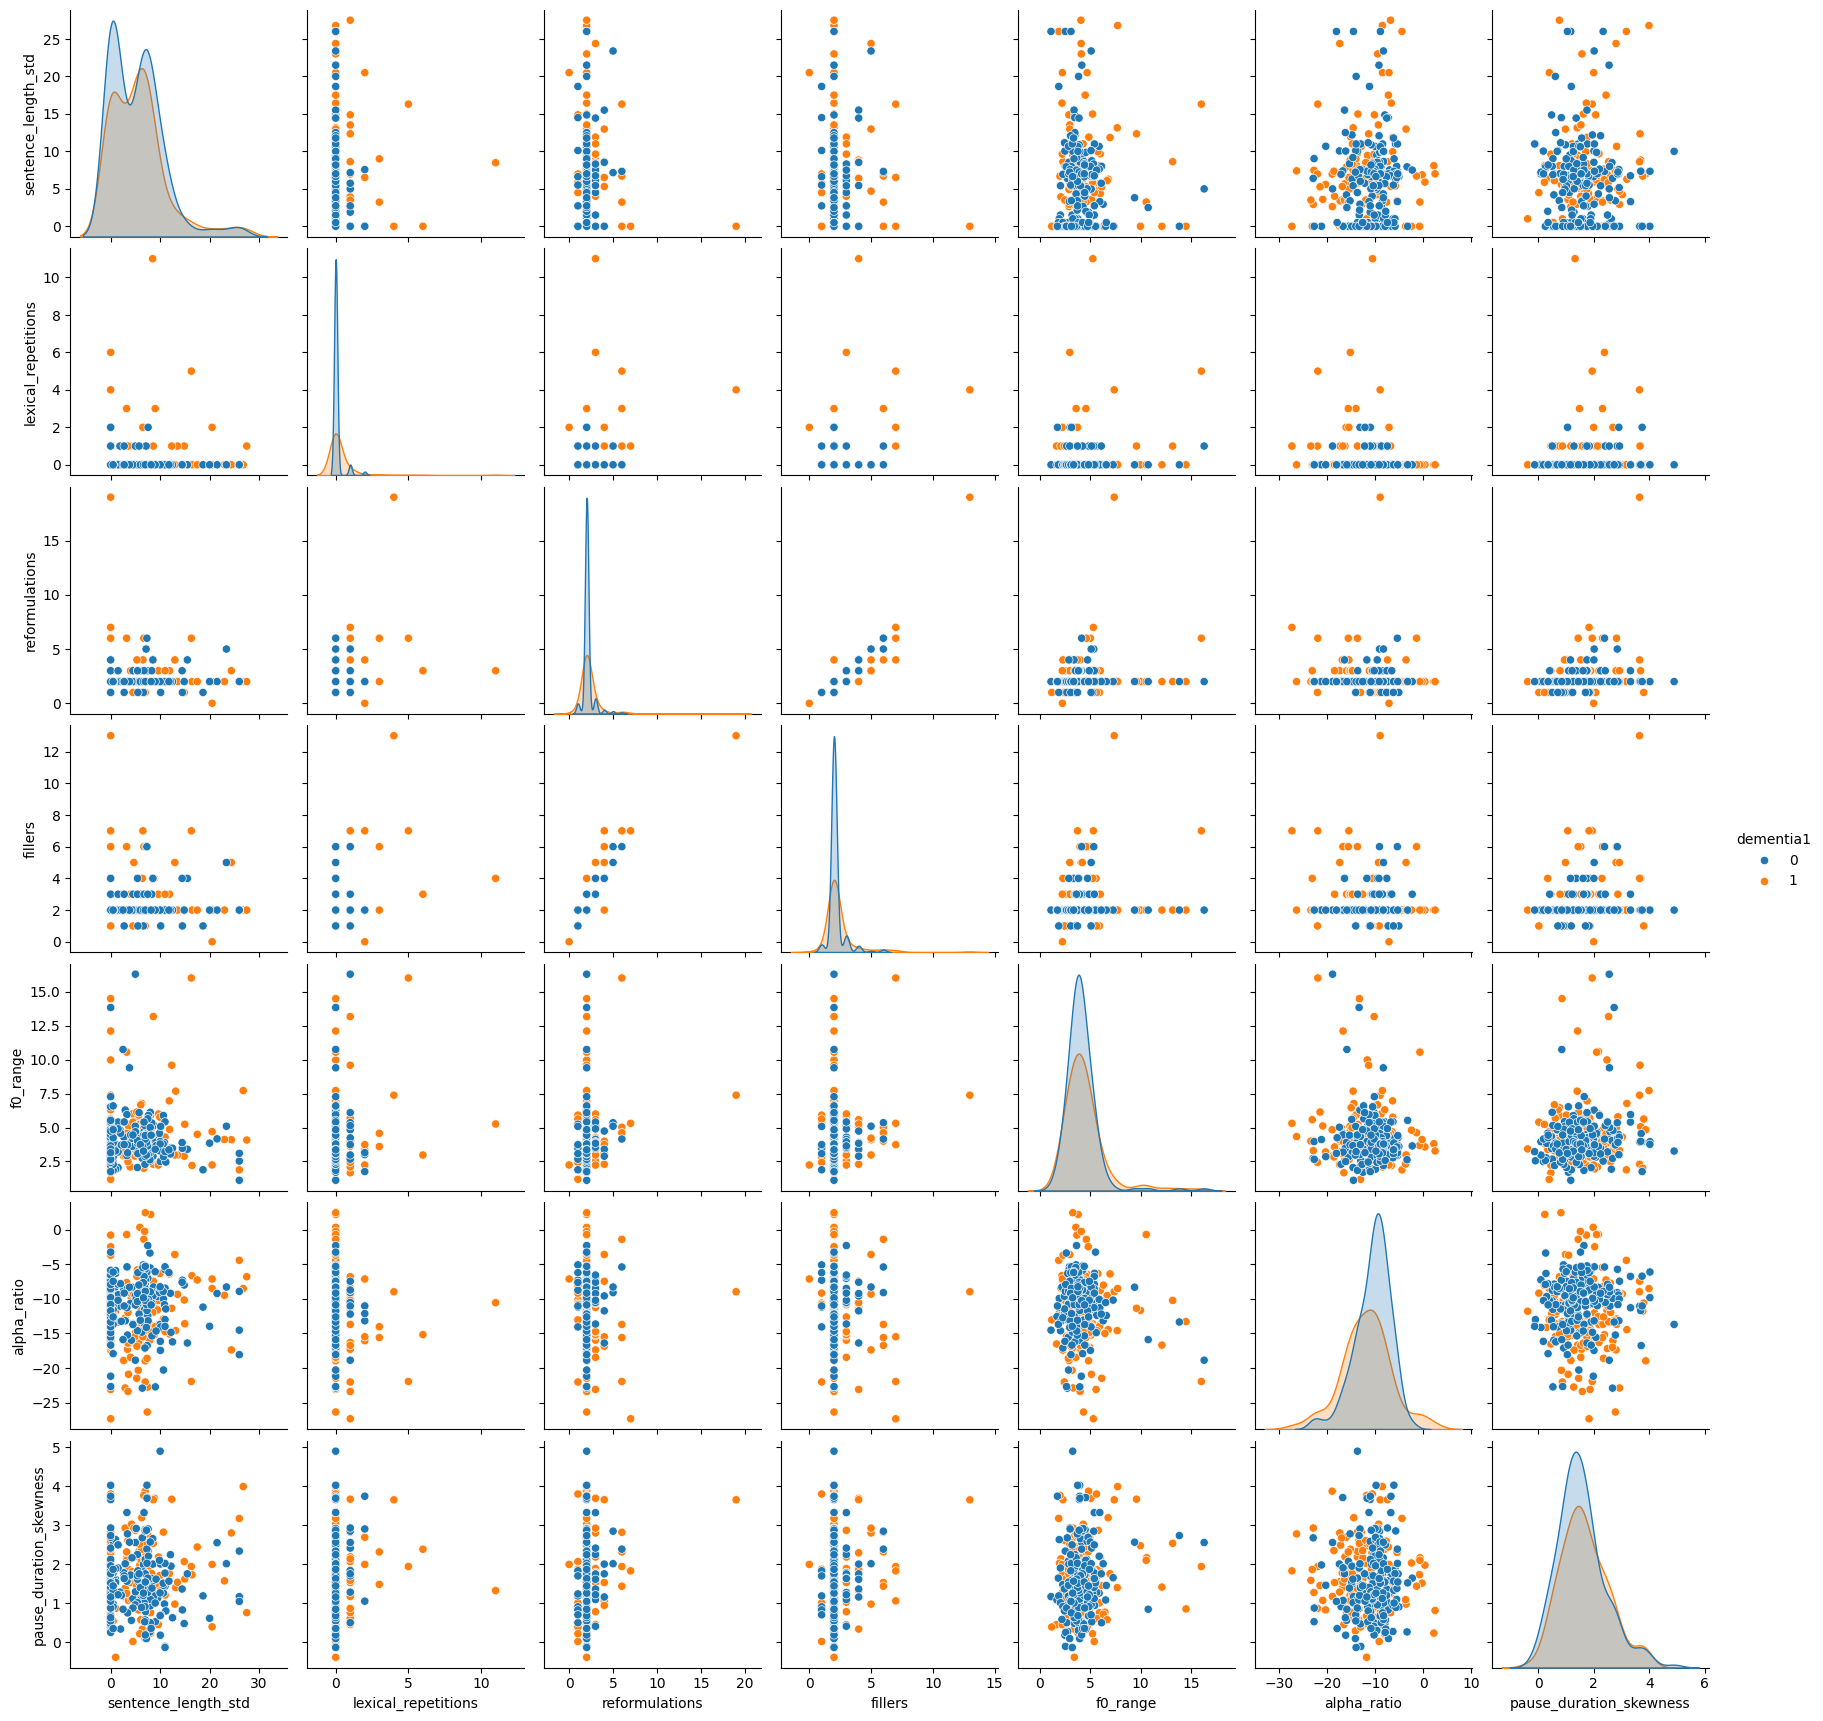

In [19]:
# variables intermedias en materia de cantidad de valores outliets

dt_inter = dt_new[['sentence_length_std', 'lexical_repetitions','reformulations',
       'fillers', 'f0_range','alpha_ratio', 'pause_duration_skewness', 'dementia1']]
pairplot_data = dt_inter
sns.pairplot(pairplot_data, hue='dementia1')

**Observaciones:**
* Se observan una serie de patrones muy interesantes en algunas de las variables graficadas en el barplot, en los cuales, los valores outliers corresponden a valores asociados con dementia=1, lo que puede resultar un factor clave de presencia de la emfermedad.
* Por consiguiente, los valores autliers no se puede reemplazar o imputar, pues son factores claves para detectar la presencia del deterioro cognitivo

## Análisis de correlaciones

In [20]:
var_num = dt.select_dtypes(include=['int64', 'float64']).columns
print(f'Matriz de Correlacioned de Pearson')
print("-"*100)
correlation_matrix = dt[var_num].corr()
display(correlation_matrix)

print("Correlaciones mas fuertes:")
print("-"*100)
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_pairs.append((
            correlation_matrix.columns[i],
            correlation_matrix.columns[j],
            correlation_matrix.iloc[i,j]
        ))
# ordernar por valor absoluto de correlaciones
corr_pairs_sorted = sorted(corr_pairs, key=lambda x:abs(x[2]), reverse=True)
print('Top 20 correlaciones mas fuertes:')
for var1, var2, corr in corr_pairs_sorted[:20]:
    print(f'{var1:20s} {var2:20s}:{corr:6.3f}')

Matriz de Correlacioned de Pearson
----------------------------------------------------------------------------------------------------


,sujeto,dementia,age,total_words,total_sentences,sentence_length_mean,sentence_length_std,type_token_ratio,mattr_50,noun_ratio,...,pause_duration_mean,pause_time_ratio,speech_segment_duration_mean,speech_segment_duration_cv,pause_duration_skewness,pause_duration_kurtosis,voiced_ratio,mmse_df_info,schooling_years,articulation_rate_wpm
sujeto,1.000000,0.046221,0.205643,-0.095947,-0.186527,0.193607,-0.140019,0.026338,-0.054373,-0.058658,...,0.092797,0.012596,0.123797,0.064186,-0.160361,-0.122187,0.026357,-0.036213,0.030746,0.015411
dementia,0.046221,1.000000,0.211819,0.122593,0.119790,-0.018116,0.024359,-0.087569,-0.129596,-0.178991,...,0.164512,-0.068453,-0.041674,0.015484,0.076958,0.083054,-0.148869,-0.699743,-0.092440,-0.372719
age,0.205643,0.211819,1.000000,0.151002,-0.000974,0.044936,0.057341,-0.121919,-0.120997,-0.068244,...,0.313742,-0.046163,0.012014,-0.012826,-0.039750,0.004956,-0.087179,-0.229406,-0.283154,-0.205517
total_words,-0.095947,0.122593,0.151002,1.000000,0.367061,0.002222,0.164161,-0.775489,-0.565522,-0.328310,...,0.060014,0.066036,0.000834,-0.075962,0.193066,0.184002,-0.080159,-0.244934,-0.029157,-0.142797
total_sentences,-0.186527,0.119790,-0.000974,0.367061,1.000000,-0.701730,0.217598,-0.230127,-0.183328,-0.117321,...,0.054495,-0.008892,-0.020096,-0.073553,0.099352,0.073617,-0.056319,-0.066016,0.000741,-0.087790
sentence_length_mean,0.193607,-0.018116,0.044936,0.002222,-0.701730,1.000000,-0.494230,-0.051013,-0.076775,0.029656,...,-0.019625,-0.036201,-0.061280,0.004260,-0.048547,-0.021291,-0.065222,-0.058606,-0.054562,-0.074517
sentence_length_std,-0.140019,0.024359,0.057341,0.164161,0.217598,-0.494230,1.000000,-0.124814,-0.052371,-0.120824,...,0.060210,-0.019104,0.044783,0.010969,0.057971,0.054636,0.065268,-0.103869,-0.036343,-0.027693
type_token_ratio,0.026338,-0.087569,-0.121919,-0.775489,-0.230127,-0.051013,-0.124814,1.000000,0.903064,0.300663,...,-0.019373,-0.107245,-0.058613,-0.000112,-0.141635,-0.128527,0.081146,0.185492,0.009817,0.038717
mattr_50,-0.054373,-0.129596,-0.120997,-0.565522,-0.183328,-0.076775,-0.052371,0.903064,1.000000,0.237338,...,-0.046122,-0.077105,-0.027305,-0.004278,-0.091587,-0.085446,0.123580,0.197289,0.010202,0.069271
noun_ratio,-0.058658,-0.178991,-0.068244,-0.328310,-0.117321,0.029656,-0.120824,0.300663,0.237338,1.000000,...,0.028570,-0.053081,0.013634,0.063906,-0.078255,-0.058703,0.113525,0.241098,0.073771,0.072259


Correlaciones mas fuertes:
----------------------------------------------------------------------------------------------------
Top 20 correlaciones mas fuertes:
speech_rate_wpm      articulation_rate_wpm: 0.999
sentence_length_mean readability         :-0.946
pause_duration_skewness pause_duration_kurtosis: 0.944
reformulations       fillers             : 0.907
type_token_ratio     mattr_50            : 0.903
duracion_s           pause_count         : 0.811
noun_ratio           idea_density        : 0.803
sentence_length_mean subordinate_sentence_ratio: 0.792
speech_rate_wpm      duracion_s          :-0.792
duracion_s           articulation_rate_wpm:-0.790
total_words          type_token_ratio    :-0.775
subordinate_sentence_ratio readability         :-0.771
f0_mean              hnr                 : 0.764
f0_std               f0_range            : 0.743
shimmer_local        hnr                 :-0.735
total_sentences      incomplete_sentence_ratio: 0.717
total_sentences      sentence

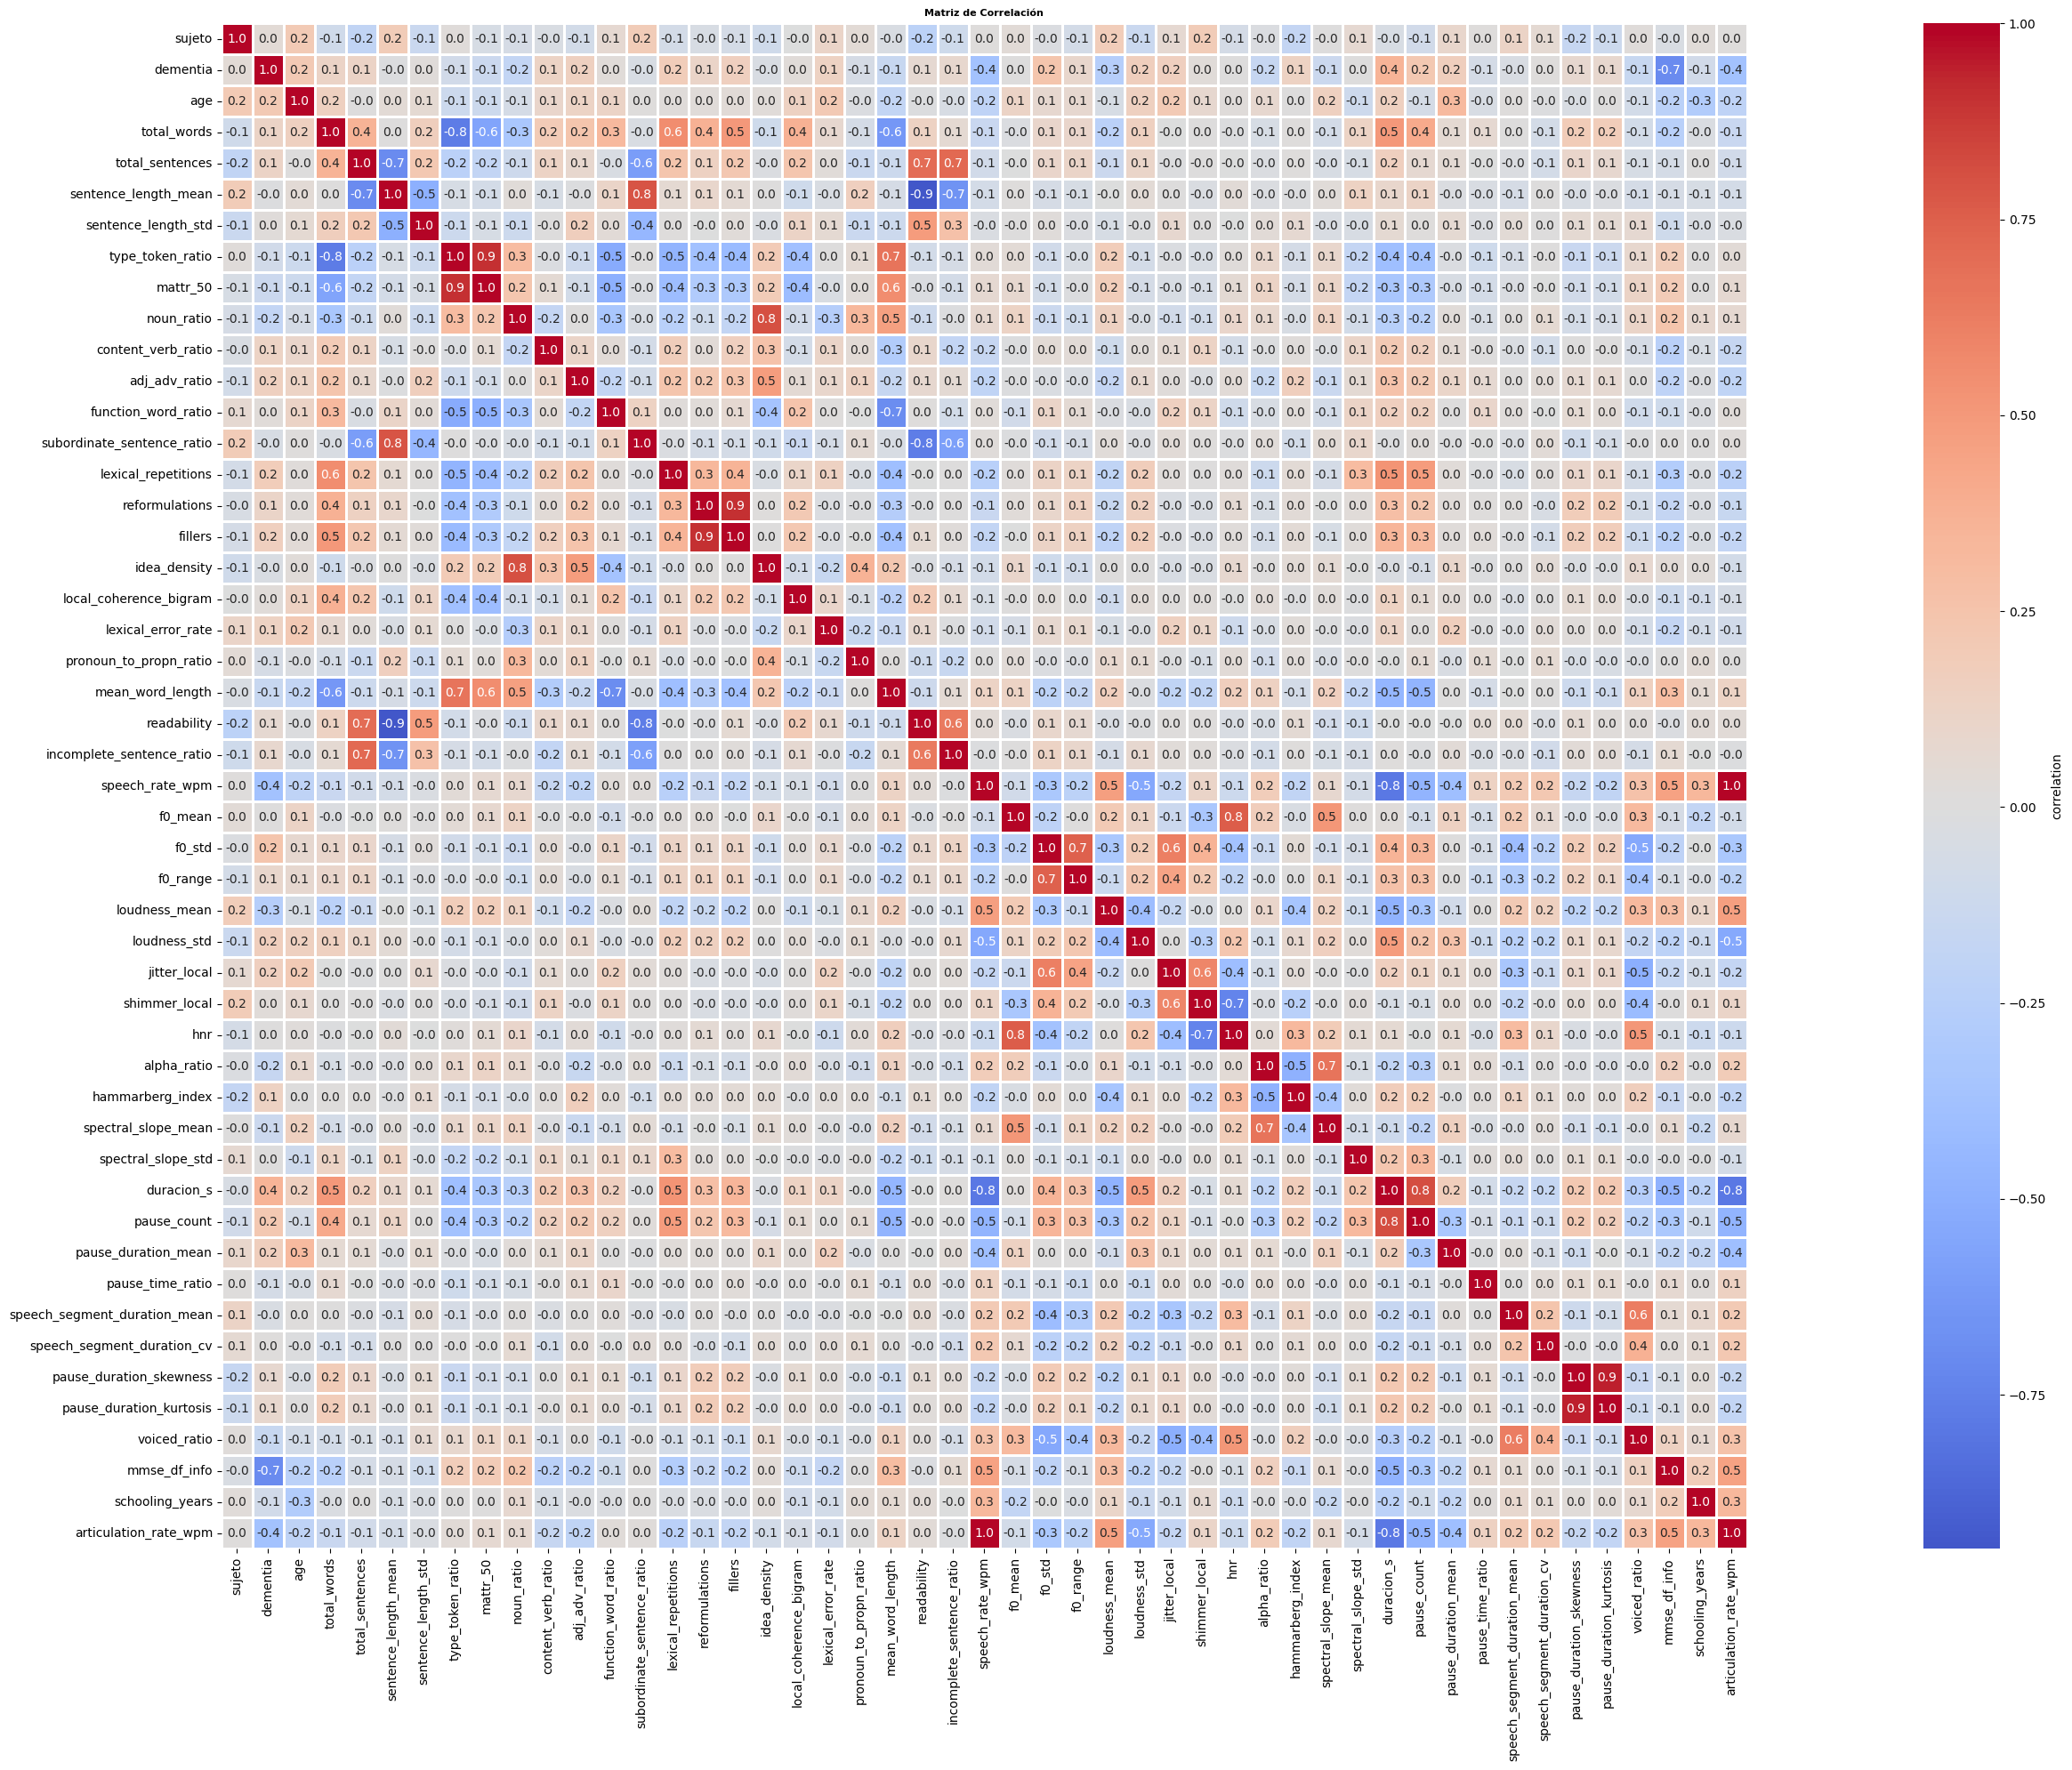

In [21]:
# Heatmap
plt.figure(figsize=(40, 20))
sns.heatmap(correlation_matrix, annot=True, fmt='.1f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={'label': 'correlation'})
plt.title("Matriz de Correlación", fontweight='bold', fontsize=8)
plt.tight_layout()
plt.show()

**Observaciones:**
* Se observan algunas asociaciones bastante fuertes entre algunas de las variables del dataset.
* Se destaca la fuerte asociación negativa entre dementia y la mmse_df_info.
* Las asociaciones lineales con la variable dependiente (dementia), son pocas por lo que se hace necesario, revisar modelos que permitan relaciones no lineales con el fin de garantizar que todas las aristas quedan cubiertas, y se pueda tener un modelo que permita detectar los sintomas del deterioro cognitivo.